In [173]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.dummy import DummyClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.model_selection import RandomizedSearchCV

In [174]:


# Load dataset
df = pd.read_csv("loan.csv", low_memory=False)

# Preview
df.head()

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,NaN,NaN,2500,2500,2500.0,36 months,13.56,84.92,C,C1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,30000,30000,30000.0,60 months,18.94,777.23,D,D2,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,5000,5000,5000.0,36 months,17.97,180.69,D,D1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,4000,4000,4000.0,36 months,18.94,146.51,D,D2,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,30000,30000,30000.0,60 months,16.14,731.78,C,C4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN


In [175]:
df.columns

Index(['id', 'member_id', 'loan_amnt', 'funded_amnt', 'funded_amnt_inv',
       'term', 'int_rate', 'installment', 'grade', 'sub_grade',
       ...
       'hardship_payoff_balance_amount', 'hardship_last_payment_amount',
       'disbursement_method', 'debt_settlement_flag',
       'debt_settlement_flag_date', 'settlement_status', 'settlement_date',
       'settlement_amount', 'settlement_percentage', 'settlement_term'],
      dtype='object', length=145)

In [176]:
df["id"]

0         NaN
1         NaN
2         NaN
3         NaN
4         NaN
           ..
2260663   NaN
2260664   NaN
2260665   NaN
2260666   NaN
2260667   NaN
Name: id, Length: 2260668, dtype: float64

In [177]:
#checking rows and columns
df.shape

(2260668, 145)

In [178]:
#checking for information about the dataset
df.info

<bound method DataFrame.info of          id  member_id  loan_amnt  funded_amnt  funded_amnt_inv        term  \
0       NaN        NaN       2500         2500           2500.0   36 months   
1       NaN        NaN      30000        30000          30000.0   60 months   
2       NaN        NaN       5000         5000           5000.0   36 months   
3       NaN        NaN       4000         4000           4000.0   36 months   
4       NaN        NaN      30000        30000          30000.0   60 months   
...      ..        ...        ...          ...              ...         ...   
2260663 NaN        NaN      12000        12000          12000.0   60 months   
2260664 NaN        NaN      12000        12000          12000.0   60 months   
2260665 NaN        NaN      10000        10000          10000.0   36 months   
2260666 NaN        NaN      12000        12000          12000.0   60 months   
2260667 NaN        NaN      16550        16550          16550.0   60 months   

         int_rate  

In [179]:
df['loan_status'].value_counts()

loan_status
Fully Paid                                             1041952
Current                                                 919695
Charged Off                                             261655
Late (31-120 days)                                       21897
In Grace Period                                           8952
Late (16-30 days)                                         3737
Does not meet the credit policy. Status:Fully Paid        1988
Does not meet the credit policy. Status:Charged Off        761
Default                                                     31
Name: count, dtype: int64

In [180]:
#checking a few variables
df[['loan_amnt', 'annual_inc', 'dti', 'grade', 'loan_status']].head()

,loan_amnt,annual_inc,dti,grade,loan_status
0,2500,55000.0,18.24,C,Current
1,30000,90000.0,26.52,D,Current
2,5000,59280.0,10.51,D,Current
3,4000,92000.0,16.74,D,Current
4,30000,57250.0,26.35,C,Current


In [181]:
missing_pct = (df.isnull().mean() * 100).sort_values(ascending=False)

missing_pct.head(25)

id                                            100.000000
url                                           100.000000
member_id                                     100.000000
orig_projected_additional_accrued_interest     99.627278
hardship_length                                99.530537
hardship_reason                                99.530537
hardship_status                                99.530537
deferral_term                                  99.530537
hardship_amount                                99.530537
hardship_start_date                            99.530537
hardship_end_date                              99.530537
payment_plan_start_date                        99.530537
hardship_dpd                                   99.530537
hardship_loan_status                           99.530537
hardship_payoff_balance_amount                 99.530537
hardship_last_payment_amount                   99.530537
hardship_type                                  99.530537
debt_settlement_flag_date      

In [182]:
sum(missing_pct > 50)

44

In [183]:
df[['loan_amnt', 'annual_inc', 'dti', 'int_rate']].describe()

,loan_amnt,annual_inc,dti,int_rate
count,2.260668e+06,2.260664e+06,2.258957e+06,2.260668e+06
mean,1.504693e+04,7.799243e+04,1.882420e+01,1.309291e+01
std,9.190245e+03,1.126962e+05,1.418333e+01,4.832114e+00
min,5.000000e+02,0.000000e+00,-1.000000e+00,5.310000e+00
25%,8.000000e+03,4.600000e+04,1.189000e+01,9.490000e+00
50%,1.290000e+04,6.500000e+04,1.784000e+01,1.262000e+01
75%,2.000000e+04,9.300000e+04,2.449000e+01,1.599000e+01
max,4.000000e+04,1.100000e+08,9.990000e+02,3.099000e+01


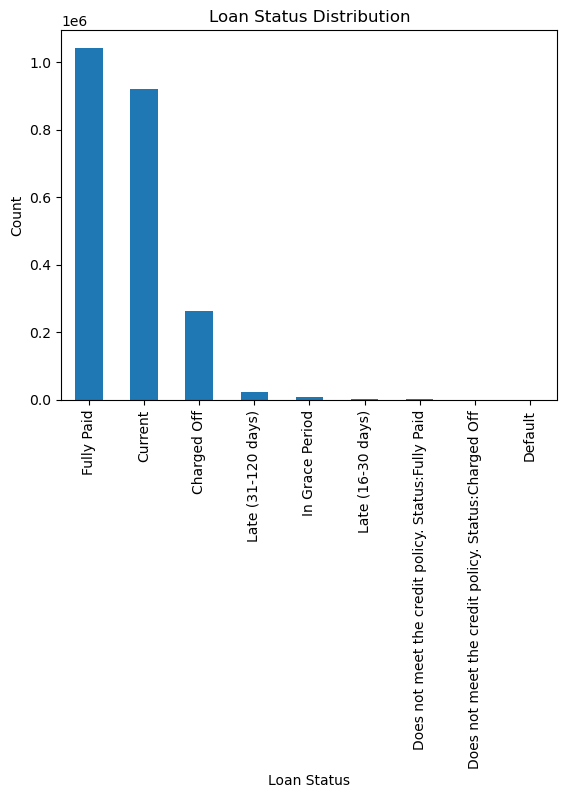

In [184]:


df['loan_status'].value_counts().plot(kind='bar')

plt.title('Loan Status Distribution')
plt.xlabel('Loan Status')
plt.ylabel('Count')

plt.show()

In [185]:
#merging columns some of the columns that have similar information and dropping only resolved outcomes
# Merge categories
df['loan_status'] = df['loan_status'].replace({
    'Does not meet the credit policy. Status:Fully Paid': 'Fully Paid',
    'Does not meet the credit policy. Status:Charged Off': 'Charged Off',
    'Default': 'Charged Off'
})

# Keep only resolved outcomes
df = df[df['loan_status'].isin(['Fully Paid', 'Charged Off'])]

In [186]:
df['loan_status'].value_counts()

loan_status
Fully Paid     1043940
Charged Off     262447
Name: count, dtype: int64

<Figure size 800x500 with 0 Axes>

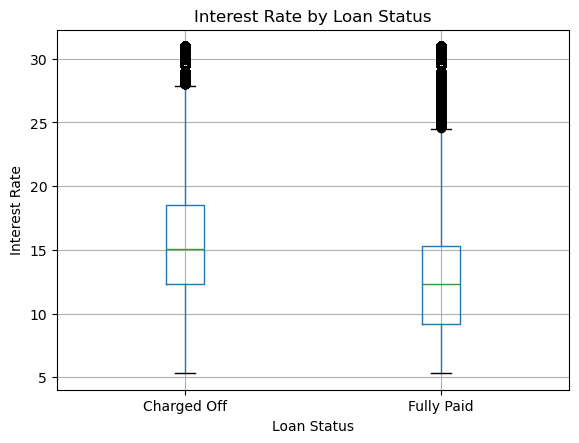

In [187]:
#Are there differences in interest rates between fully paid and charged off loans?

plt.figure(figsize=(8,5))

df.boxplot(column='int_rate', by='loan_status')

plt.title('Interest Rate by Loan Status')
plt.suptitle('')
plt.xlabel('Loan Status')
plt.ylabel('Interest Rate')

plt.show()

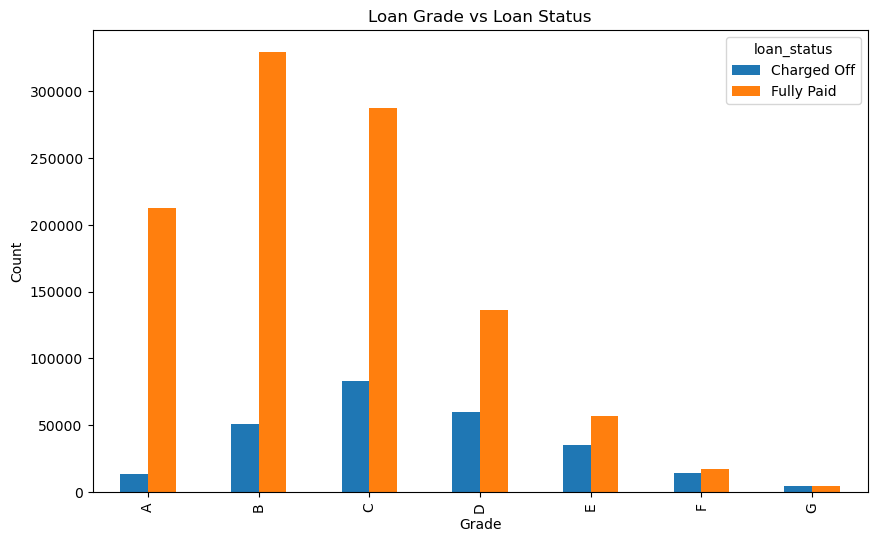

In [188]:
#Are there differences in loan amounts between fully paid and charged off loans?
grade_default = pd.crosstab(df['grade'], df['loan_status'])

grade_default.plot(kind='bar', figsize=(10,6))

plt.title('Loan Grade vs Loan Status')
plt.xlabel('Grade')
plt.ylabel('Count')

plt.show()

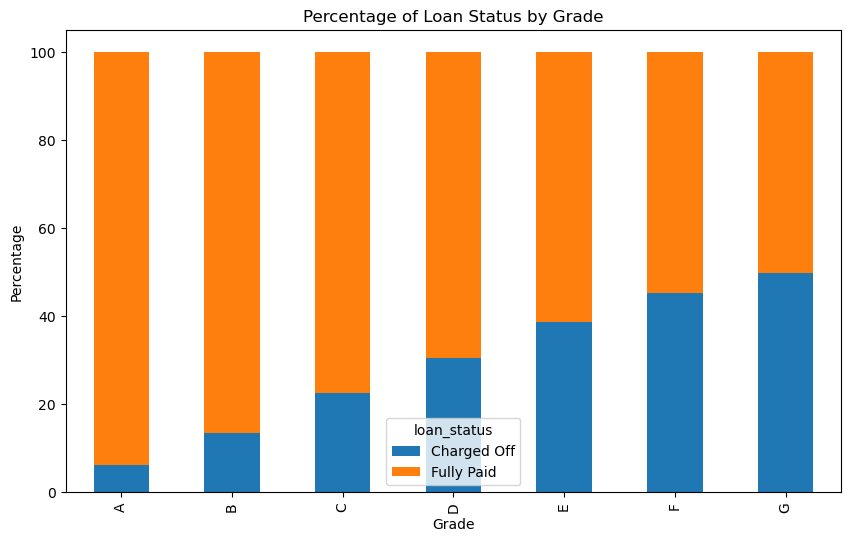

In [189]:
#What percentage of loans in each grade are fully paid vs charged off?
grade_pct = pd.crosstab(
    df['grade'],
    df['loan_status'],
    normalize='index'
) * 100

grade_pct.plot(kind='bar', stacked=True, figsize=(10,6))
plt.title('Percentage of Loan Status by Grade')
plt.xlabel('Grade')
plt.ylabel('Percentage')

plt.show()

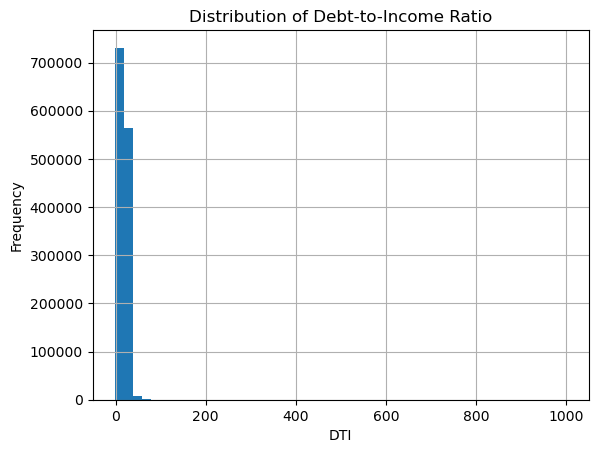

In [190]:
#What is the distribution of debt-to-income ratio (dti) among borrowers?
df['dti'].hist(bins=50)

plt.title('Distribution of Debt-to-Income Ratio')
plt.xlabel('DTI')
plt.ylabel('Frequency')

plt.show()

In [191]:
#What are the top 20 highest debt-to-income ratios in the dataset?
df['dti'].sort_values(ascending=False).head(20)

1557520    999.0
513826     999.0
1527957    999.0
1569972    999.0
1420415    999.0
1542272    999.0
1369872    999.0
848880     999.0
1505223    999.0
626147     999.0
2145595    999.0
938145     999.0
874223     999.0
1415693    999.0
1447698    999.0
418369     999.0
1536743    999.0
1461219    999.0
259055     999.0
896343     999.0
Name: dti, dtype: float64

In [192]:
df['dti'].quantile([0.90, 0.95, 0.99, 0.999])

0.900    29.73000
0.950    32.93000
0.990    38.37000
0.999    64.05926
Name: dti, dtype: float64

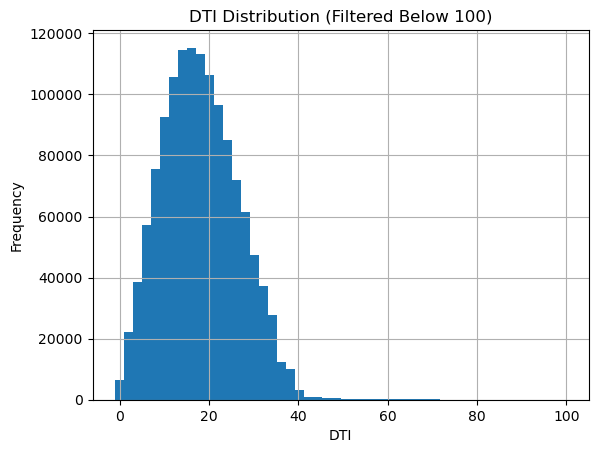

In [193]:
#What does the distribution of dti look like if we filter out extreme values above 100?
df[df['dti'] < 100]['dti'].hist(bins=50)

plt.title('DTI Distribution (Filtered Below 100)')
plt.xlabel('DTI')
plt.ylabel('Frequency')

plt.show()

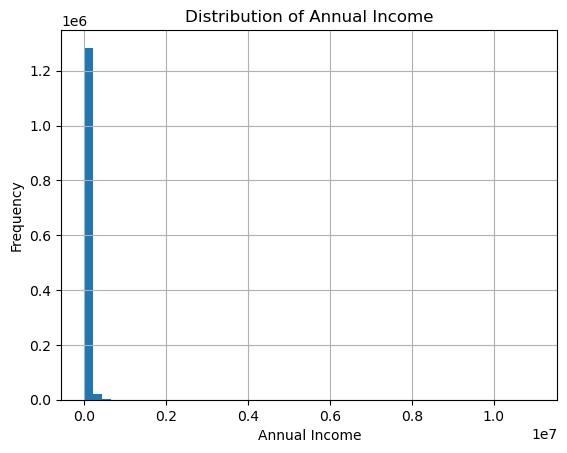

In [194]:
#What is the distribution of annual income among borrowers?
df['annual_inc'].hist(bins=50)

plt.title('Distribution of Annual Income')
plt.xlabel('Annual Income')
plt.ylabel('Frequency')

plt.show()

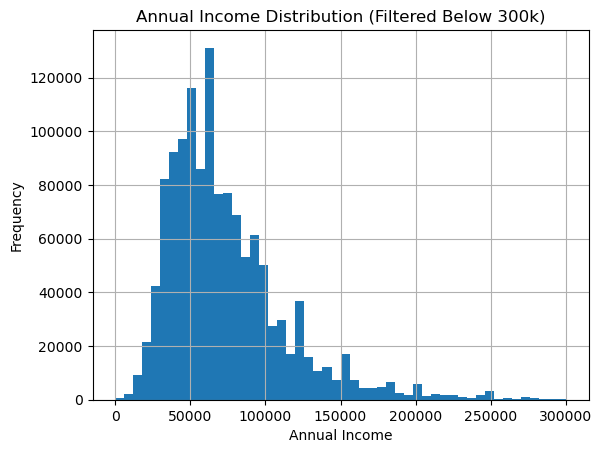

In [195]:
#What does the distribution of annual income look like if we filter out extreme values above 300k?
df[df['annual_inc'] < 300000]['annual_inc'].hist(bins=50)

plt.title('Annual Income Distribution (Filtered Below 300k)')
plt.xlabel('Annual Income')
plt.ylabel('Frequency')

plt.show()

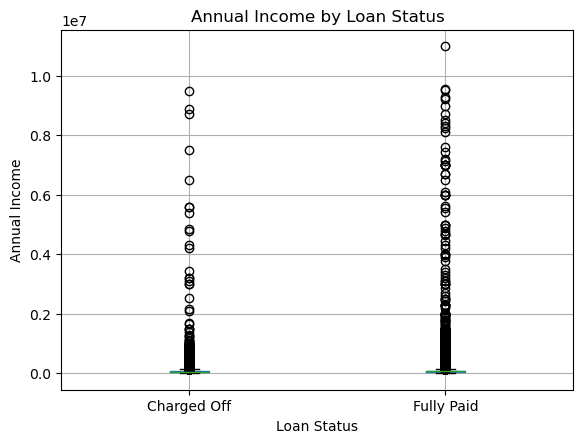

In [196]:
#Are there differences in annual income between fully paid and charged off loans?
df.boxplot(column='annual_inc', by='loan_status')

plt.title('Annual Income by Loan Status')
plt.suptitle('')
plt.xlabel('Loan Status')
plt.ylabel('Annual Income')

plt.show()

In [197]:
#checking cardinality of categorical variables
categorical_cols = df.select_dtypes(include='object').columns

df[categorical_cols].nunique().sort_values(ascending=False)

emp_title                    372941
desc                         124202
title                         63147
zip_code                        945
earliest_cr_line                738
sec_app_earliest_cr_line        560
last_credit_pull_d              140
issue_d                         139
last_pymnt_d                    135
next_pymnt_d                    100
settlement_date                  89
debt_settlement_flag_date        82
addr_state                       51
sub_grade                        35
hardship_start_date              26
payment_plan_start_date          25
hardship_end_date                24
purpose                          14
emp_length                       11
hardship_reason                   9
grade                             7
home_ownership                    6
hardship_loan_status              5
verification_status_joint         3
verification_status               3
hardship_status                   3
settlement_status                 3
disbursement_method         

In [198]:
numeric_df = df.select_dtypes(include=['int64', 'float64'])

corr_matrix = numeric_df.corr()

corr_matrix

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,int_rate,installment,annual_inc,url,dti,...,deferral_term,hardship_amount,hardship_length,hardship_dpd,orig_projected_additional_accrued_interest,hardship_payoff_balance_amount,hardship_last_payment_amount,settlement_amount,settlement_percentage,settlement_term
id,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
member_id,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
loan_amnt,NaN,NaN,1.000000,0.999529,0.998151,0.143566,0.953386,0.310283,NaN,0.032594,...,NaN,0.704677,NaN,0.043412,0.701029,0.835159,0.486038,0.805400,-0.056944,0.219991
funded_amnt,NaN,NaN,0.999529,1.000000,0.998734,0.143660,0.954080,0.310170,NaN,0.033017,...,NaN,0.704677,NaN,0.043412,0.701029,0.835159,0.486038,0.805511,-0.056767,0.220617
funded_amnt_inv,NaN,NaN,0.998151,0.998734,1.000000,0.143737,0.952644,0.309615,NaN,0.034179,...,NaN,0.704561,NaN,0.043380,0.700839,0.835104,0.486033,0.805153,-0.057177,0.221309
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
hardship_payoff_balance_amount,NaN,NaN,0.835159,0.835159,0.835104,0.322741,0.751008,0.387327,NaN,0.027073,...,NaN,0.895336,NaN,0.018491,0.899963,1.000000,0.485671,0.950536,-0.010531,0.314654
hardship_last_payment_amount,NaN,NaN,0.486038,0.486038,0.486033,0.214946,0.462674,0.246764,NaN,0.018383,...,NaN,0.432325,NaN,0.071152,0.450602,0.485671,1.000000,0.526628,0.006853,0.156001
settlement_amount,NaN,NaN,0.805400,0.805511,0.805153,0.316518,0.738594,0.195311,NaN,0.044906,...,NaN,0.869781,NaN,0.070428,0.854968,0.950536,0.526628,1.000000,0.190509,0.258092
settlement_percentage,NaN,NaN,-0.056944,-0.056767,-0.057177,-0.014612,-0.042787,-0.005401,NaN,0.006567,...,NaN,0.016775,NaN,-0.011997,-0.013190,-0.010531,0.006853,0.190509,1.000000,0.052372


In [199]:
corr_pairs = (
    corr_matrix
    .abs()
    .unstack()
    .sort_values(ascending=False)
)

corr_pairs = corr_pairs[corr_pairs < 1]

corr_pairs.head(20)

orig_projected_additional_accrued_interest  hardship_amount                               1.000000
hardship_amount                             orig_projected_additional_accrued_interest    1.000000
loan_amnt                                   funded_amnt                                   0.999529
funded_amnt                                 loan_amnt                                     0.999529
total_pymnt                                 total_pymnt_inv                               0.999042
total_pymnt_inv                             total_pymnt                                   0.999042
funded_amnt                                 funded_amnt_inv                               0.998734
funded_amnt_inv                             funded_amnt                                   0.998734
open_acc                                    num_sats                                      0.998717
num_sats                                    open_acc                                      0.998717
funded_amn

In [200]:
#finding columns with high leakage potential
for col in df.columns:
    if 'pymnt' in col or 'recover' in col or 'settlement' in col:
        print(col)

pymnt_plan
total_pymnt
total_pymnt_inv
recoveries
collection_recovery_fee
last_pymnt_d
last_pymnt_amnt
next_pymnt_d
debt_settlement_flag
debt_settlement_flag_date
settlement_status
settlement_date
settlement_amount
settlement_percentage
settlement_term


In [201]:
leakage_cols = [
    'total_pymnt',
    'total_pymnt_inv',
    'recoveries',
    'collection_recovery_fee',
    'last_pymnt_d',
    'last_pymnt_amnt',
    'next_pymnt_d',
    'debt_settlement_flag',
    'debt_settlement_flag_date',
    'settlement_status',
    'settlement_date',
    'settlement_amount',
    'settlement_percentage',
    'settlement_term'
]

In [202]:
def wrangle(filepath):

    # Load dataset
    df = pd.read_csv(filepath, low_memory=False)

    # Merge loan outcome categories
    df['loan_status'] = df['loan_status'].replace({
        'Does not meet the credit policy. Status:Fully Paid': 'Fully Paid',
        'Does not meet the credit policy. Status:Charged Off': 'Charged Off',
        'Default': 'Charged Off'
    })

    # Keep only resolved loan outcomes
    df = df[df['loan_status'].isin(['Fully Paid', 'Charged Off'])]

    # Drop columns with more than 50% missing values
    threshold = 0.50
    missing_pct = df.isnull().mean()
    cols_to_drop = missing_pct[missing_pct > threshold].index
    df = df.drop(columns=cols_to_drop)

    # Remove leakage variables
    leakage_cols = [
        'total_pymnt',
        'total_pymnt_inv',
        'recoveries',
        'collection_recovery_fee',
        'last_pymnt_d',
        'last_pymnt_amnt',
        'next_pymnt_d',
        'debt_settlement_flag',
        'debt_settlement_flag_date',
        'settlement_status',
        'settlement_date',
        'settlement_amount',
        'settlement_percentage',
        'settlement_term',
        'out_prncp',
        'out_prncp_inv'
    ]

    df = df.drop(columns=leakage_cols, errors='ignore')

# Replace extreme DTI values with missing values
    df.loc[df['dti'] > 100, 'dti'] = np.nan

# Create binary target variable
    df['default'] = df['loan_status'].map({
    'Fully Paid': 0,
    'Charged Off': 1
    })

    # Remove high-cardinality and low-information categorical variables
    high_cardinality_cols = [
        'emp_title',
        'title',
        'zip_code',
        'earliest_cr_line',
        'issue_d',
        'last_credit_pull_d',
        'loan_status',
        'pymnt_plan',
        'total_rec_prncp',
        'total_rec_int',
        'total_rec_late_fee',
        'policy_code',
        'hardship_flag'
    ]

    df = df.drop(columns=high_cardinality_cols, errors='ignore')

     # Remove highly redundant variables
    redundant_cols = [
        'funded_amnt',
        'funded_amnt_inv',
        'num_sats',
        'grade'
    ]

    df = df.drop(columns=redundant_cols, errors='ignore')   
    return df

In [203]:
df = wrangle("loan.csv")

df.shape

(1306387, 62)

## Model Building

In [204]:
target = 'default'

X = df.drop(columns=target)
y = df[target]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1306387, 61)
y shape: (1306387,)


In [205]:
# Split into train and test sets with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (1045109, 61)
X_test: (261278, 61)
y_train: (1045109,)
y_test: (261278,)


In [206]:
#Identify categorical and numeric columns
categorical_cols = X_train.select_dtypes(include='object').columns.tolist()

numeric_cols = [
    col for col in X_train.columns
    if col not in categorical_cols
]

print("Categorical columns:", len(categorical_cols))
print("Numeric columns:", len(numeric_cols))

Categorical columns: 10
Numeric columns: 51


In [207]:
#Create column transformer for preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
        ('num', 'passthrough', numeric_cols)
    ]
)

In [208]:
#Create baseline model pipeline
baseline_model = Pipeline([
    ("preprocessing", preprocessor),
    ("classifier", DummyClassifier(strategy="most_frequent"))
])

baseline_model.fit(X_train, y_train)

y_pred_baseline = baseline_model.predict(X_test)

print("Baseline Accuracy:", accuracy_score(y_test, y_pred_baseline))
print("Baseline Precision:", precision_score(y_test, y_pred_baseline, zero_division=0))
print("Baseline Recall:", recall_score(y_test, y_pred_baseline))
print("Baseline F1:", f1_score(y_test, y_pred_baseline))
print(confusion_matrix(y_test, y_pred_baseline))

Baseline Accuracy: 0.799102871271213
Baseline Precision: 0.0
Baseline Recall: 0.0
Baseline F1: 0.0
[[208788      0]
 [ 52490      0]]


In [209]:
#Create random forest model pipeline
rf_model = Pipeline([
    ("preprocessing", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1,
        class_weight='balanced'
    ))
])

In [210]:
#Train random forest model
rf_model.fit(X_train, y_train)

,steps,"[('preprocessing', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [211]:
#Make predictions
y_pred_rf = rf_model.predict(X_test)

In [212]:
#Evaluate random forest model
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Random Forest Precision:", precision_score(y_test, y_pred_rf))
print("Random Forest Recall:", recall_score(y_test, y_pred_rf))
print("Random Forest F1:", f1_score(y_test, y_pred_rf))

print(confusion_matrix(y_test, y_pred_rf))

Random Forest Accuracy: 0.8013150743652355
Random Forest Precision: 0.552891654465593
Random Forest Recall: 0.057553819775195275
Random Forest F1: 0.10425509887151879
[[206345   2443]
 [ 49469   3021]]


In [213]:
# Analyze feature importance
feature_names = rf_model.named_steps['preprocessing'].get_feature_names_out()

importances = rf_model.named_steps['classifier'].feature_importances_

feature_importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
})

feature_importance_df = feature_importance_df.sort_values(
    by='importance',
    ascending=False
)

feature_importance_df.head(20)

,feature,importance
130,num__int_rate,0.058467
133,num__dti,0.032375
131,num__installment,0.028612
148,num__bc_open_to_buy,0.026409
132,num__annual_inc,0.026399
139,num__revol_util,0.026140
147,num__avg_cur_bal,0.026115
138,num__revol_bal,0.025263
176,num__tot_hi_cred_lim,0.025180
152,num__mo_sin_old_il_acct,0.024993


In [214]:
#Calculate predicted probabilities for the default class
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

In [215]:
#Create binary predictions using a 0.30 threshold
y_pred_30 = (y_prob_rf >= 0.30).astype(int)

In [216]:
#Evaluate model with 0.30 threshold
print("Accuracy:", accuracy_score(y_test, y_pred_30))
print("Precision:", precision_score(y_test, y_pred_30))
print("Recall:", recall_score(y_test, y_pred_30))
print("F1:", f1_score(y_test, y_pred_30))

print(confusion_matrix(y_test, y_pred_30))

Accuracy: 0.7567801345693094
Precision: 0.39541877884542637
Recall: 0.3982663364450372
F1: 0.3968374494580383
[[176825  31963]
 [ 31585  20905]]


In [217]:
#Calculate ROC curve and AUC score
fpr, tpr, thresholds = roc_curve(y_test, y_prob_rf)

auc_score = roc_auc_score(y_test, y_prob_rf)

print("AUC Score:", auc_score)

AUC Score: 0.7109728265668555


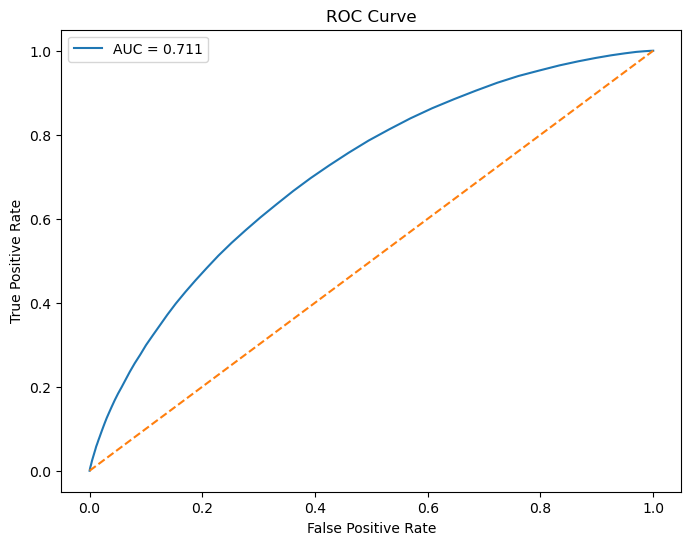

In [218]:
plt.figure(figsize=(8,6))

plt.plot(fpr, tpr, label=f"AUC = {auc_score:.3f}")

plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()

plt.show()

In [219]:
thresholds_to_try = [0.1, 0.2, 0.3, 0.4, 0.5]

for threshold in thresholds_to_try:

    y_pred_thresh = (y_prob_rf >= threshold).astype(int)

    print(f"\nThreshold: {threshold}")

    print("Precision:", precision_score(y_test, y_pred_thresh))
    print("Recall:", recall_score(y_test, y_pred_thresh))
    print("F1:", f1_score(y_test, y_pred_thresh))


Threshold: 0.1
Precision: 0.23691755067543233
Recall: 0.9398933130120023
F1: 0.378441818453785

Threshold: 0.2
Precision: 0.30872545543568186
Recall: 0.6967231853686416
F1: 0.42786110396143856

Threshold: 0.3
Precision: 0.39541877884542637
Recall: 0.3982663364450372
F1: 0.3968374494580383

Threshold: 0.4
Precision: 0.4777601270849881
Recall: 0.18334920937321394
F1: 0.2649998623234298

Threshold: 0.5
Precision: 0.5435339308578745
Recall: 0.06469803772147076
F1: 0.11563212911573428


In [220]:
feature_names = rf_model.named_steps['preprocessing'].get_feature_names_out()

importances = rf_model.named_steps['classifier'].feature_importances_

feature_importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
})

feature_importance_df = feature_importance_df.sort_values(
    by='importance',
    ascending=False
)

feature_importance_df.head(20)

,feature,importance
130,num__int_rate,0.058467
133,num__dti,0.032375
131,num__installment,0.028612
148,num__bc_open_to_buy,0.026409
132,num__annual_inc,0.026399
139,num__revol_util,0.026140
147,num__avg_cur_bal,0.026115
138,num__revol_bal,0.025263
176,num__tot_hi_cred_lim,0.025180
152,num__mo_sin_old_il_acct,0.024993


In [221]:
feature_importance_df.tail(20)

,feature,importance
169,num__num_tl_30dpd,1.574822e-04
113,cat__addr_state_SD,1.483691e-04
32,cat__sub_grade_G1,1.457034e-04
71,cat__purpose_wedding,1.455763e-04
122,cat__addr_state_WY,1.388749e-04
79,cat__addr_state_DC,1.371885e-04
118,cat__addr_state_VT,1.232804e-04
33,cat__sub_grade_G2,1.210869e-04
85,cat__addr_state_ID,8.880799e-05
100,cat__addr_state_ND,8.635779e-05


In [222]:
param_grid = {
    "classifier__n_estimators": [100, 200],
    "classifier__max_depth": [8, 12, 16, None],
    "classifier__min_samples_leaf": [5, 10, 25, 50],
    "classifier__max_features": ["sqrt", "log2"]
}

In [223]:
rf_tune_model = Pipeline([
    ("preprocessing", preprocessor),
    ("classifier", RandomForestClassifier(
        random_state=42,
        n_jobs=-1,
        class_weight="balanced"
    ))
])

In [224]:
rf_search = RandomizedSearchCV(
    estimator=rf_tune_model,
    param_distributions=param_grid,
    n_iter=8,
    scoring="f1",
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=2
)

In [225]:
rf_search.fit(X_train, y_train)

Fitting 3 folds for each of 8 candidates, totalling 24 fits


,estimator,Pipeline(step...m_state=42))])
,param_distributions,"{'classifier__max_depth': [8, 12, ...], 'classifier__max_features': ['sqrt', 'log2'], 'classifier__min_samples_leaf': [5, 10, ...], 'classifier__n_estimators': [100, 200]}"
,n_iter,8
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,3
,verbose,2
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [226]:
rf_search.best_params_

{'classifier__n_estimators': 100,
 'classifier__min_samples_leaf': 25,
 'classifier__max_features': 'sqrt',
 'classifier__max_depth': 16}

In [227]:
best_rf_model = rf_search.best_estimator_

y_pred_tuned = best_rf_model.predict(X_test)

print("Tuned Random Forest Accuracy:", accuracy_score(y_test, y_pred_tuned))
print("Tuned Random Forest Precision:", precision_score(y_test, y_pred_tuned))
print("Tuned Random Forest Recall:", recall_score(y_test, y_pred_tuned))
print("Tuned Random Forest F1:", f1_score(y_test, y_pred_tuned))

print(confusion_matrix(y_test, y_pred_tuned))

Tuned Random Forest Accuracy: 0.6695971340870643
Tuned Random Forest Precision: 0.3311678591743257
Tuned Random Forest Recall: 0.632234711373595
Tuned Random Forest F1: 0.4346590350951873
[[141765  67023]
 [ 19304  33186]]
